In [7]:
import numpy as np
import sympy as sp
from sympy.physics.mechanics import *
from scipy.integrate import solve_ivp
import scipy.linalg as la
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import welib
init_vprinting()

# 3 DOF
## Tilting Nacelle, Single Flexible Blade

In [8]:
# ==========================================
# Symbols and Generalized Coordinates
# ==========================================
t = dynamicsymbols._t
g = sp.symbols('g')                          

# Generalised coordinates and speeds
theta, psi, q = dynamicsymbols('theta psi q')   
theta_d, psi_d, q_d = dynamicsymbols('theta psi q', 1)

# Nacelle parameters 
m_n = sp.symbols('m_n')                     
k_t, c_t = sp.symbols('k_t c_t')           
J_xx_n, J_yy_n, J_zz_n = sp.symbols('J_xx_n J_yy_n J_zz_n')  
X_n, Z_n = sp.symbols('X_n Z_n')
X_h, Z_h = sp.symbols('X_h Z_h')

# Blade & Modal parameters 
m_b   = sp.symbols('m_b')                   
Z_b   = sp.symbols('Z_b')                   
GM_b  = sp.symbols('GM_b')                  # modal mass
K_b   = sp.symbols('K_b')                   # modal stiffness
M_phi = sp.symbols('M_phi')                 # coupling integral: ∫ φ(r) dm
M_rphi= sp.symbols('M_rphi')                # coupling integral: ∫ r φ(r) dm

J_xx_b, J_yy_b, J_zz_b = sp.symbols('J_xx_b J_yy_b J_zz_b')

In [9]:
# ==========================================
# Reference Frames and Kinematics
# ==========================================
N = ReferenceFrame('N')                          
A = N.orientnew('A', 'Axis', [theta, N.y])      
B = A.orientnew('B', 'Axis', [psi,   A.x])      

# Angular velocities
A.set_ang_vel(N, theta_d * N.y)                             
B.set_ang_vel(A, psi_d * A.x)                             

# Geometry (Points)
O    = Point('O')                                            
NCOM = O.locatenew('NCOM', X_n * A.x + Z_n * A.z)         
Hub  = O.locatenew('Hub',  X_h * A.x + Z_h * A.z)         

# Treat BCOM as the UNDEFORMED rigid center of mass to prevent PyDy 
# from double-counting the kinetic energy of the deflection 'q'
BCOM_rigid = Hub.locatenew('BCOM_rigid', Z_b * B.z)

# Velocities
O.set_vel(N, 0)                                             
NCOM.v2pt_theory(O, N, A)
Hub.v2pt_theory(O, N, A)
BCOM_rigid.v2pt_theory(Hub, N, B)

In [10]:
# ==========================================
# Inertias and Rigid Bodies
# ==========================================
J_nac   = inertia(A, J_xx_n, J_yy_n, J_zz_n)    
J_blade = inertia(B, J_xx_b, J_yy_b, J_zz_b)    

Nacelle = RigidBody('Nacelle', NCOM, A, m_n, (J_nac, NCOM))
Blade   = RigidBody('Blade', BCOM_rigid, B, m_b, (J_blade, BCOM_rigid))

In [11]:
# ==========================================
# Energy and Lagrangian formulation
# ==========================================
# Potential Energy (Gravity + Stiffness)
Nacelle.potential_energy = m_n * g * NCOM.pos_from(O).dot(N.z) 
Blade.potential_energy   = m_b * g * BCOM_rigid.pos_from(O).dot(N.z)
V_flex = sp.Rational(1, 2) * K_b * q**2 + sp.Rational(1, 2) * k_t * theta**2

# Flexible Kinetic Energy and Coupling
# Modal mass kinetic energy
T_flex = sp.Rational(1, 2) * GM_b * q_d**2

# FFRF Coupling kinetic energy (Translation and Rotation)
v_hub = Hub.vel(N)
omega_b = B.ang_vel_in(N)
T_coupling = q_d * M_phi * v_hub.dot(B.x) + q_d * M_rphi * omega_b.dot(B.y)

# Total Lagrangian
L_rigid = Lagrangian(N, Nacelle, Blade)
L = L_rigid + T_flex + T_coupling - V_flex

# Damping forcelist
damping = [(A, -c_t * theta_d * N.y)]

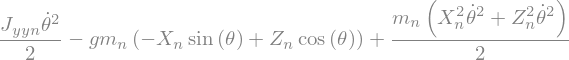

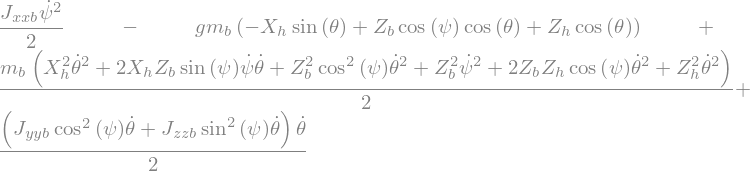

In [12]:
display(Lagrangian(N, Nacelle))
display(Lagrangian(N, Blade))

In [13]:
LM = LagrangesMethod(L, [theta, psi, q], frame=N, forcelist=damping)
eom = LM.form_lagranges_equations()

--- Mass Matrix ---


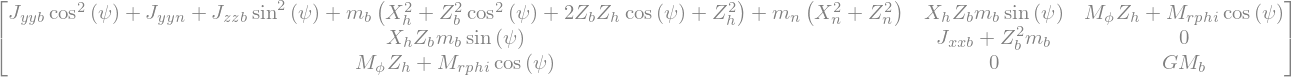


--- Forcing Term ---


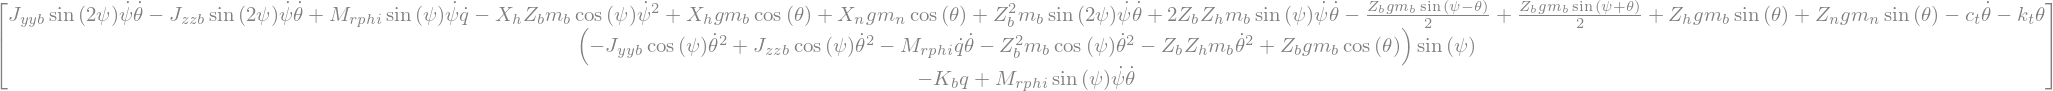

Equations of Motion:


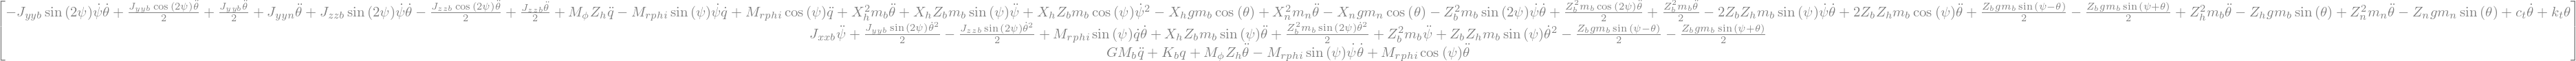

In [14]:
# Output
print('--- Mass Matrix ---')
display(sp.simplify(sp.trigsimp(LM.mass_matrix)))

print('\n--- Forcing Term ---')
display(sp.simplify(sp.trigsimp(LM.forcing)))

print("Equations of Motion:")
display(sp.simplify(sp.trigsimp(eom)))

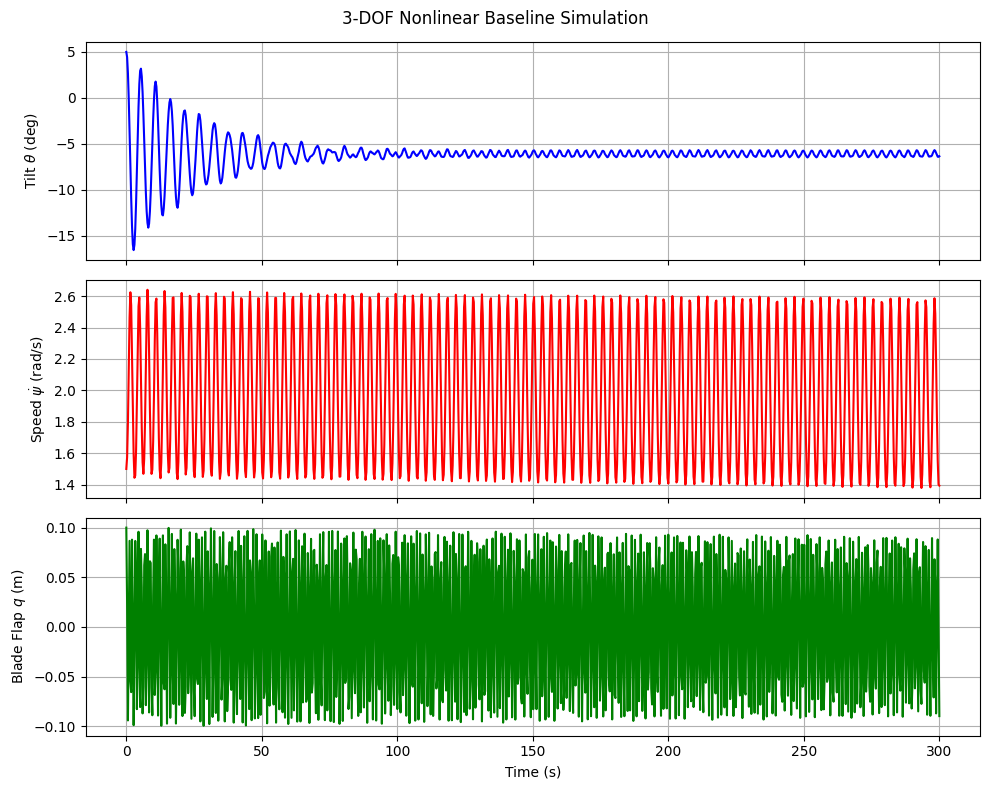

In [15]:
# ==========================================
# Parameters for 3-DOF
# ==========================================
params = {
    m_n: 50000,     
    m_b: 10000,     
    J_yy_n: 5e6, 
    J_xx_b: 1e5,    
    J_yy_b: 1e6,    
    J_zz_b: 1e6,    
    X_n: -1.5,      
    Z_n: 2.0,       
    X_h: -2.0,      
    Z_h: 3.0,       
    Z_b: 1.5,       
    k_t: 1e7,       
    c_t: 5e5,       
    g: 9.81,         
    # Flexible Parameters
    GM_b: 8000,     # Generalized mass (slightly less than total blade mass)
    K_b: 1e7,       # Stiffness (defines the flap frequency)
    M_phi: 5000,    # Coupling: ∫ φ dm
    M_rphi: 60000   # Coupling: ∫ r φ dm
}

# 2. Lambdify the 3rd DOF
M_sub = LM.mass_matrix.subs(params)
F_sub = LM.forcing.subs(params)

# Define the 6-element state vector: [pos1, pos2, pos3, vel1, vel2, vel3]
states = [theta, psi, q, theta_d, psi_d, q_d]

M_func = sp.lambdify((states,), M_sub, modules='numpy')
F_func = sp.lambdify((states,), F_sub, modules='numpy')

# ==========================================
# 3. 3-DOF ODE Function
# ==========================================
def ode_3dof(t, y):
    # y = [theta, psi, q, theta_dot, psi_dot, q_dot]
    
    # Solve M(q) * q_ddot = F(q, q_dot)
    M_num = M_func(y)
    F_num = F_func(y)
    
    # Extract accelerations [theta_ddot, psi_ddot, q_ddot]
    accels = np.linalg.solve(M_num, F_num).flatten()
    
    # Return [vel1, vel2, vel3, acc1, acc2, acc3]
    return [y[3], y[4], y[5], accels[0], accels[1], accels[2]]

# ==========================================
# 4. Run Simulation
# ==========================================
# Init: 5 deg tilt, 0 azimuth, 0.1m deflection, 0 tilt rate, 1.5 rad/s spin, 0 flap rate
init_3dof = [np.deg2rad(5), 0.0, 0.1, 0.0, 1.5, 0.0]

t_span = (0, 300) 
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(ode_3dof, t_span, init_3dof, t_eval=t_eval, method='RK45')

# ==========================================
# 5. Visualizing the Baseline
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(sol.t, np.rad2deg(sol.y[0]), 'b')
ax1.set_ylabel('Tilt $\\theta$ (deg)')

ax2.plot(sol.t, sol.y[4], 'r')
ax2.set_ylabel('Speed $\\dot{\\psi}$ (rad/s)')

ax3.plot(sol.t, sol.y[2], 'g')
ax3.set_ylabel('Blade Flap $q$ (m)')
ax3.set_xlabel('Time (s)')

for ax in [ax1, ax2, ax3]: ax.grid(True)
plt.suptitle('3-DOF Nonlinear Baseline Simulation')
plt.tight_layout()
plt.show()

### Linearize

--- 3-DOF Flexible Linearized Matrices ---
Mass Matrix (M_lin_3dof):


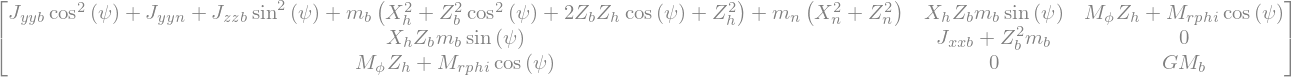


Damping/Gyroscopic Matrix (C_lin_3dof):


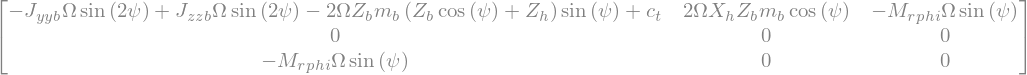


Stiffness/Centrifugal Matrix (K_lin_3dof):


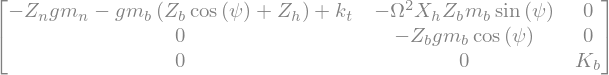

In [16]:
import sympy as sp

# 1. Define the steady-state operating point variables
Omega = sp.Symbol('Omega', real=True, positive=True) # Constant rotor speed
q0 = sp.Symbol('q0', real=True)                      # Steady-state blade deflection

# 2. Define the Operating Point Dictionary
# Nacelle is stationary, Rotor is spinning, Blade is deflected but not vibrating
op_point_3dof = {
    theta: 0,
    theta.diff(t): 0,
    psi.diff(t): Omega,
    q: q0,
    q.diff(t): 0
}

# 3. Define State Vectors for Jacobians (Now 3x1)
q_vec_3dof = sp.Matrix([theta, psi, q])
qd_vec_3dof = sp.Matrix([theta.diff(t), psi.diff(t), q.diff(t)])

# 4. Extract and Linearize the Mass Matrix
M_lin_3dof = sp.simplify(LM.mass_matrix.subs(op_point_3dof))

# 5. Extract and Linearize C and K Matrices using Jacobians
forcing_3dof = LM.forcing

C_lin_3dof = sp.simplify(-forcing_3dof.jacobian(qd_vec_3dof).subs(op_point_3dof))
K_lin_3dof = sp.simplify(-forcing_3dof.jacobian(q_vec_3dof).subs(op_point_3dof))

print("--- 3-DOF Flexible Linearized Matrices ---")
print("Mass Matrix (M_lin_3dof):")
display(M_lin_3dof)
print("\nDamping/Gyroscopic Matrix (C_lin_3dof):")
display(C_lin_3dof)
print("\nStiffness/Centrifugal Matrix (K_lin_3dof):")
display(K_lin_3dof)

### Eigenvalue Analysis

Flexible Blade, Tilting Nacelle State-Space A Matrix:


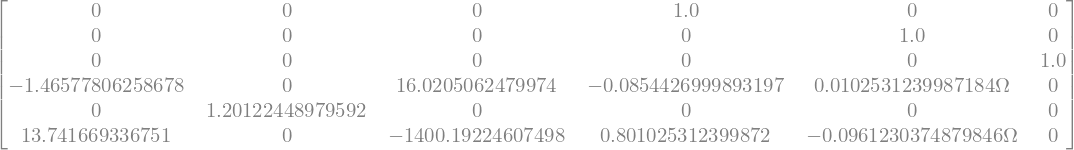

In [17]:
# State-space A matrix construction

# Define the operating point dictionary
op_dict = {
    theta: 0,
    theta.diff(t): 0,
    theta.diff(t, 2): 0,
    psi.diff(t): Omega,
    psi.diff(t, 2): 0,
    q: q0,         
    q.diff(t): 0,
    q.diff(t, 2): 0  
}

# 2. Extract the un-inverted matrices (A_and_B=False is the default)
M_sym, A_sym, B_sym, _ = LM.linearize(
    q_ind=[theta, psi, q], 
    qd_ind=[theta.diff(t), psi.diff(t), q.diff(t)], 
    op_point=op_dict
)

subs_dict = {**params, psi: 0, Omega: Omega} 

M_sub = M_sym.subs(subs_dict)
A_sub = A_sym.subs(subs_dict)

# 4. Create the final State-Space A matrix safely
q0_val = 0 
A_state_space_3dof = sp.expand(M_sub.inv() * A_sub).evalf()

print("Flexible Blade, Tilting Nacelle State-Space A Matrix:")
display(A_state_space_3dof)

In [21]:
# -------------------------------------------------------
# Evaluate at a specific rotor speed
# -------------------------------------------------------
OMEGA_VAL = 1.5  # rad/s (~14 RPM)
A_evaluated = A_state_space_3dof.subs(Omega, OMEGA_VAL)

# Convert to NumPy
A_num = np.array(A_evaluated.tolist(), dtype=np.float64)

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = la.eig(A_num)

# DOF index -> name mapping (positions 0-2 correspond to theta, psi, q)
dof_names = {0: "Nacelle Tilt", 1: "Rotor Azimuth", 2: "Blade Flapwise Bending"}

print("=== 3-DOF Eigenvalue Analysis Results ===")
print(f"Operating Speed: Omega = {OMEGA_VAL} rad/s\n")

for i, lam in enumerate(eigenvalues):
    # Filter numerical noise
    if np.abs(lam) < 1e-4:
        continue

    if np.abs(np.imag(lam)) > 1e-4:
        # Oscillatory mode — print positive-imaginary half only
        if np.imag(lam) > 0:
            wn_rad = np.abs(lam)
            wn_hz  = wn_rad / (2 * np.pi)
            zeta   = -np.real(lam) / wn_rad

            # Use eigenvector participation to name the mode
            dominant_dof = np.argmax(np.abs(eigenvectors[:, i])) % 3
            mode_name = dof_names.get(dominant_dof, "Unknown")

            print(f"Mode: {mode_name}")
            print(f"  Eigenvalue (λ): {np.real(lam):.4f} ± {np.imag(lam):.4f}j")
            print(f"  Natural Frequency (ω_n): {wn_hz:.4f} Hz  ({wn_rad:.4f} rad/s)")
            print(f"  Damping Ratio (ζ): {zeta:.4f}")
            print("-" * 40)
    else:
        # Real root — only print once (positive root of the ± pair)
        if np.real(lam) > 0:
            dominant_dof = np.argmax(np.abs(eigenvectors[:, i])) % 3
            mode_name = dof_names.get(dominant_dof, "Unknown")

            print(f"Mode: {mode_name} (Non-Oscillatory)")
            print(f"  Eigenvalue (λ): {lam:.6f}")
            print(f"  Time Constant (τ): {1/np.abs(np.real(lam)):.4f} seconds")
            status = "UNSTABLE (Exponential Divergence)" if np.real(lam) > 0 else "STABLE (Exponential Decay)"
            print(f"  STATUS: {status}")
            print("-" * 40)

=== 3-DOF Eigenvalue Analysis Results ===
Operating Speed: Omega = 1.5 rad/s

Mode: Blade Flapwise Bending
  Eigenvalue (λ): -0.0046 ± 37.4212j
  Natural Frequency (ω_n): 5.9558 Hz  (37.4212 rad/s)
  Damping Ratio (ζ): 0.0001
----------------------------------------
Mode: Nacelle Tilt
  Eigenvalue (λ): -0.0381 ± 1.1432j
  Natural Frequency (ω_n): 0.1821 Hz  (1.1439 rad/s)
  Damping Ratio (ζ): 0.0333
----------------------------------------
Mode: Rotor Azimuth (Non-Oscillatory)
  Eigenvalue (λ): 1.096004+0.000000j
  Time Constant (τ): 0.9124 seconds
  STATUS: UNSTABLE (Exponential Divergence)
----------------------------------------


### Simulate Linearized Model

--- Linearized System Stability Analysis ---
Operating Speed: Omega = 1.5 rad/s

Mode 1:
  Eigenvalue (λ): -0.0046+37.4212j
  Time Constant (τ): 217.8136 seconds
  STATUS: STABLE (Exponential Decay)
Mode 2:
  Eigenvalue (λ): -0.0046-37.4212j
  Time Constant (τ): 217.8136 seconds
  STATUS: STABLE (Exponential Decay)
Mode 3:
  Eigenvalue (λ): -0.0381+1.1432j
  Time Constant (τ): 26.2259 seconds
  STATUS: STABLE (Exponential Decay)
Mode 4:
  Eigenvalue (λ): -0.0381-1.1432j
  Time Constant (τ): 26.2259 seconds
  STATUS: STABLE (Exponential Decay)
Mode 5:
  Eigenvalue (λ): 1.0960+0.0000j
  Time Constant (τ): 0.9124 seconds
  STATUS: UNSTABLE (Exponential Divergence)
Mode 6:
  Eigenvalue (λ): -1.0960+0.0000j
  Time Constant (τ): 0.9124 seconds
  STATUS: STABLE (Exponential Decay)


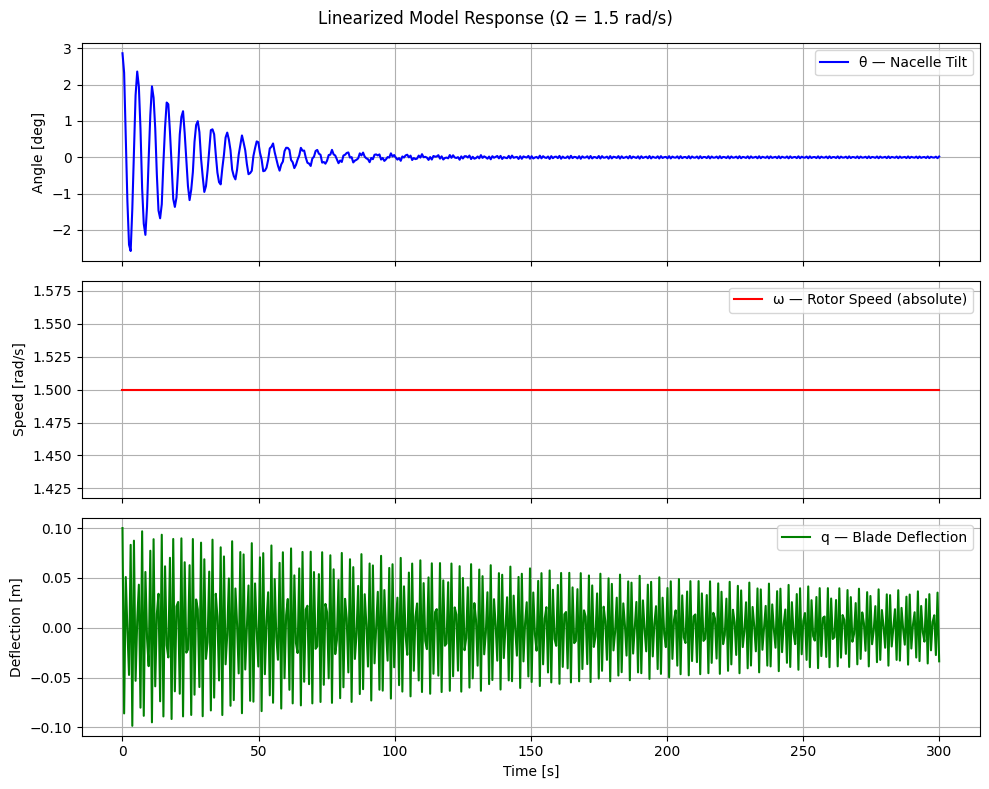

In [22]:
# -------------------------------------------------------
# Shared rotor speed and steady-state deflection
# -------------------------------------------------------
OMEGA_VAL = 1.5  # rad/s — must match eigenvalue section
Q0_VAL    = 0.0  # steady-state blade deflection (m)

# Define the operating point — spinning rotor, consistent with eigenvalue section
op_dict = {
    theta: 0,
    theta.diff(t): 0,
    theta.diff(t, 2): 0,
    psi.diff(t): Omega,   # spinning, not stopped
    psi.diff(t, 2): 0,
    q: q0,
    q.diff(t): 0,
    q.diff(t, 2): 0
}

# Single unified parameter dict (same as used throughout the notebook)
p_vals = {
    g: 9.81,
    m_n: 50000,
    m_b: 10000,
    J_xx_n: 1e6,
    J_yy_n: 5e6,
    J_zz_n: 1e6,
    J_xx_b: 1e5,
    J_yy_b: 1e6,
    J_zz_b: 1e6,
    X_n: -1.5,
    Z_n:  2.0,
    X_h: -2.0,
    Z_h:  3.0,
    Z_b:  1.5,
    k_t: 1e7,
    c_t: 5e5,
    GM_b: 8000,
    K_b:  1e7,
    M_phi:  5000,
    M_rphi: 60000
}

# Ensure EOM are fully formed before linearizing
LM.form_lagranges_equations()

# Extract un-inverted matrices (avoids SymPy hanging on symbolic inversion)
M_sym, A_sym_uninv, B_sym, _ = LM.linearize(
    q_ind=[theta, psi, q],
    qd_ind=[theta.diff(t), psi.diff(t), q.diff(t)],
    op_point=op_dict
)

# Substitute everything: parameters + psi=0 + Omega + q0
subs_dict = {**p_vals, psi: 0, Omega: OMEGA_VAL, q0: Q0_VAL}
M_sub = M_sym.subs(subs_dict)
A_sub = A_sym_uninv.subs(subs_dict)

# Convert to NumPy float arrays
M_num       = np.array(M_sub.evalf().tolist(), dtype=np.float64)
A_num_uninv = np.array(A_sub.evalf().tolist(), dtype=np.float64)

# Final state-space A matrix: A = M^-1 * A_uninv
A_num = la.inv(M_num) @ A_num_uninv

# -------------------------------------------------------
# Stability analysis
# -------------------------------------------------------
eigenvalues, eigenvectors = la.eig(A_num)

print("--- Linearized System Stability Analysis ---")
print(f"Operating Speed: Omega = {OMEGA_VAL} rad/s\n")

for i, lam in enumerate(eigenvalues):
    real_part = 0.0 if np.abs(np.real(lam)) < 1e-10 else np.real(lam)

    print(f"Mode {i+1}:")
    print(f"  Eigenvalue (λ): {lam:.4f}")
    if real_part > 0:
        print(f"  Time Constant (τ): {1/np.abs(real_part):.4f} seconds")
        print("  STATUS: UNSTABLE (Exponential Divergence)")
    elif real_part < 0:
        print(f"  Time Constant (τ): {1/np.abs(real_part):.4f} seconds")
        print("  STATUS: STABLE (Exponential Decay)")
    else:
        print("  STATUS: MARGINALLY STABLE (Oscillatory)")

# -------------------------------------------------------
# Simulate the linearized model
# -------------------------------------------------------
# x represents PERTURBATIONS from the operating point:
# x = [Δθ, Δψ, Δq, Δθ̇, Δψ̇, Δq̇]
x0     = np.array([0.05, 0.0, 0.1, 0.0, 0.0, 0.0])
t_span = (0, 300)
t_eval = np.linspace(t_span[0], t_span[1], 500)

def lin_sys_dynamics(t, x):
    return A_num @ x

sol = solve_ivp(lin_sys_dynamics, t_span, x0, t_eval=t_eval, method='RK45')

# -------------------------------------------------------
# Reconstruct absolute states from perturbations + operating point
# x_absolute = x_operating_point + Δx
# -------------------------------------------------------
theta_abs = sol.y[0, :]                       # op point = 0, so Δθ = θ_abs
psi_dot_abs = OMEGA_VAL + sol.y[4, :]         # Ω + Δψ̇ (Speed perturbation is index 4)
q_abs     = Q0_VAL + sol.y[2, :]              # q0 + Δq

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(sol.t, np.rad2deg(theta_abs), color='b', label='θ — Nacelle Tilt')
axs[0].set_ylabel('Angle [deg]')
axs[0].legend()
axs[0].grid(True)

# Updated Axis: Plotting absolute rotor speed instead of position
axs[1].plot(sol.t, psi_dot_abs, color='r', label='ω — Rotor Speed (absolute)')
axs[1].set_ylabel('Speed [rad/s]')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(sol.t, q_abs, color='g', label='q — Blade Deflection')
axs[2].set_ylabel('Deflection [m]')
axs[2].set_xlabel('Time [s]')
axs[2].legend()
axs[2].grid(True)

plt.suptitle(f'Linearized Model Response (Ω = {OMEGA_VAL} rad/s)')
plt.tight_layout()
plt.show()

### Validate Linearization with Integration

Simulating Nonlinear Baseline...
Simulating Linearized State-Space...


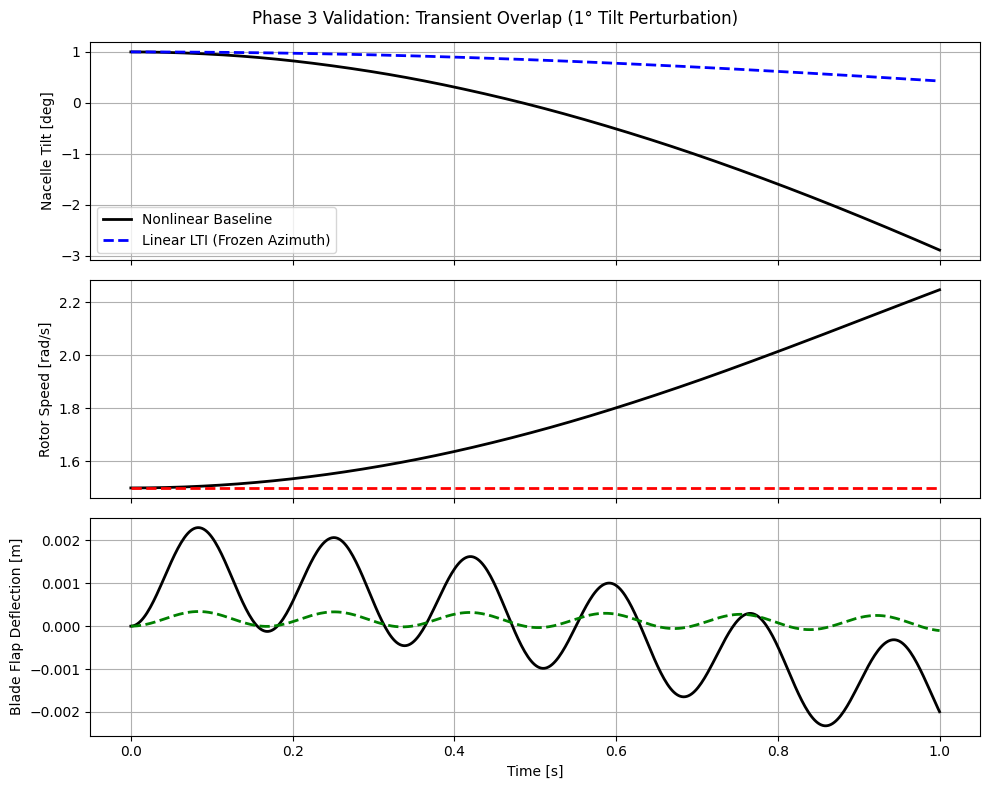

In [23]:
# =====================================================================
# Phase 3: Validate Linearization via Integration (Transient Overlap)
# =====================================================================

# 1. Define the Linear ODE Function
def ode_linear_3dof(t, x_delta):
    # dx/dt = A * x
    # x_delta is the perturbation state vector: 
    # [delta_theta, delta_psi, delta_q, delta_theta_dot, delta_psi_dot, delta_q_dot]
    return A_num @ x_delta

# 2. Define Initial Conditions (1-degree tilt perturbation)
theta_pert = np.deg2rad(1.0)

# Linear Initial Conditions (Perturbations from equilibrium)
# x_delta_0 = [th, psi, q, th_d, psi_d, q_d]
init_linear = [theta_pert, 0.0, 0.0, 0.0, 0.0, 0.0]

# Nonlinear Initial Conditions (Absolute states)
# We add the perturbation to the steady-state operating point
# Assuming q0 = 0 for the steady-state deflection in this conservative model
init_nonlinear = [theta_pert, 0.0, 0.0, 0.0, OMEGA_VAL, 0.0] 

# 3. Setup Simulation Time
t_span = (0, 1)  # Simulate for 1.5 seconds to capture the transient overlap and divergence
t_eval = np.linspace(t_span[0], t_span[1], 500)

# 4. Integrate Both Models
print("Simulating Nonlinear Baseline...")
sol_nonlin = solve_ivp(ode_3dof, t_span, init_nonlinear, t_eval=t_eval, method='RK45')

print("Simulating Linearized State-Space...")
sol_lin = solve_ivp(ode_linear_3dof, t_span, init_linear, t_eval=t_eval, method='RK45')

# 5. Convert Linear Perturbations back to Absolute States for Comparison
# Total State = Operating Point + Perturbation
theta_lin_abs = np.rad2deg(sol_lin.y[0] + 0.0)
psi_d_lin_abs = sol_lin.y[4] + OMEGA_VAL
q_lin_abs     = sol_lin.y[2] + 0.0  # Add q0 here if you calculated a non-zero steady-state deflection

# Convert Nonlinear States
theta_nonlin_abs = np.rad2deg(sol_nonlin.y[0])
psi_d_nonlin_abs = sol_nonlin.y[4]
q_nonlin_abs     = sol_nonlin.y[2]

# 6. Plot the Validation
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Nacelle Tilt
axs[0].plot(sol_nonlin.t, theta_nonlin_abs, 'k-', lw=2, label='Nonlinear Baseline')
axs[0].plot(sol_lin.t, theta_lin_abs, 'b--', lw=2, label='Linear LTI (Frozen Azimuth)')
axs[0].set_ylabel('Nacelle Tilt [deg]')
axs[0].legend()

# Rotor Speed
axs[1].plot(sol_nonlin.t, psi_d_nonlin_abs, 'k-', lw=2)
axs[1].plot(sol_lin.t, psi_d_lin_abs, 'r--', lw=2)
axs[1].set_ylabel('Rotor Speed [rad/s]')

# Blade Flapwise Deflection
axs[2].plot(sol_nonlin.t, q_nonlin_abs, 'k-', lw=2)
axs[2].plot(sol_lin.t, q_lin_abs, 'g--', lw=2)
axs[2].set_ylabel('Blade Flap Deflection [m]')
axs[2].set_xlabel('Time [s]')

for ax in axs:
    ax.grid(True)

plt.suptitle('Phase 3 Validation: Transient Overlap (1° Tilt Perturbation)')
plt.tight_layout()
plt.show()